# BTRL Transition Network — Hyperparameter Optimisation (Optuna)

## Multi-Objective Search: World-Model Quality × Reward Signal × Goal-Path Accuracy

**Environment**: DeepSea-5, deterministic (5×5 grid, 25 one-hot states)
**Config base**: `configs/config_vector-setting1.yaml`

**Objectives** (all minimised — 3-D Pareto-front via NSGA-II):
1. **Mean grid distance** — mean Euclidean distance in (row, col) space between
   each sampled hypothesis prediction and the true next state, averaged across
   100 world hypotheses M̂ and all test cases. Lower = more accurate posterior.
2. **Reward prediction MSE** — squared error between the reward head's output and
   the true reward (1 at goal state 24, 0 everywhere else), averaged across all
   test (state, action) pairs. Lower = better value-function training signal →
   proxy for "the agent will actually get the reward".
3. **Goal-path grid distance** — mean_grid_dist restricted to test cases where
   `current_state ≥ obs_space // 2` (bottom half of the grid, states 12–24 in
   DeepSea-5). These are the goal-approach transitions; getting them right drives
   shorter paths to the goal → proxy for "fewer steps to reach the reward".

**Dropped from v1**: `env_steps_to_accuracy` — completely degenerate in the first
run (all 100 trials returned 2000; `TARGET_GRID_DIST = 0.5` was never achieved).

**Not an objective**: `epochs_to_converge` — training artifact, not downstream RL
quality. Tracked as `user_attr` for inspection.

**Why grid distance, not flat-index accuracy or variance?**
DeepSea states are flat indices into an N×N grid: state `s` → `(s//N, s%N)`.
Flat-index arithmetic is misleading at row boundaries — indices 4 and 5 have
flat-diff=1 but are actually on opposite ends of adjacent rows (Euclidean dist≈4.1
in a 5×5 grid). Grid distance correctly treats states as spatial positions.

**Key design**: Evaluation always uses `lock_all_dropouts()` (EpisodeLockedDropout fix).
Each of the 100 iterations samples a fresh world hypothesis M̂; distance is measured
from each hypothesis prediction to the true state.

**Parameters tuned**: `hidden_dim`, `heads` (jointly), `learning_rate`,
`num_encoder_layers`, `forward_expansion`, `p_seq`, `p_attn`

In [6]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from copy import deepcopy
from ruamel.yaml import YAML
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import json
from torch.nn import functional as F
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
pd.options.display.max_rows = 200
pd.options.display.float_format = '{:.5f}'.format

print(f'PyTorch {torch.__version__}  |  Optuna {optuna.__version__}')


PyTorch 2.13.0+cu130  |  Optuna 4.9.0


In [7]:
from TRL.networks.transition import Network as TransitionNetwork
from notebook_utils import (
    generate_transition_data,
    test_model_locked,
    test_model_unlocked,
    early_stopping_train,
)


In [8]:
CONFIG_PATH = "configs/config_vector-setting1.yaml"
with open(CONFIG_PATH, "r") as f:
    yaml = YAML(typ='rt')
    config = yaml.load(f)

# Fixed overrides for this experiment
compute_on = 'cuda' if torch.cuda.is_available() else 'cpu'
config['gpu'] = torch.device(compute_on)
print('Device:', compute_on)
config['experiment']['deterministic']   = True    # deterministic DeepSea
config['experiment']['env']             = '5'     # depth = 5


print('Config:', CONFIG_PATH)
print('Transition params:', dict(config['transition']))
print('Env:', config['experiment']['env'],
      '| Deterministic:', config['experiment']['deterministic'])


Device: cpu
Config: configs/config_vector-setting1.yaml
Transition params: {'obs_type': 'grid', 'training_iterations': 20, 'hidden_dim': 256, 'learning_rate': 0.001, 'window_length': 3, 'context_length': 2, 'num_encoder_layers': 1, 'heads': 1, 'forward_expansion': 2, 'p_seq': 0.1, 'p_attn': 0.15}
Env: 5 | Deterministic: True


In [9]:
TIME_LIMIT = 2000   # transitions — generated ONCE and shared across all trials

episodes, test_transitions, obs_space, possible_actions = generate_transition_data(
    config, TIME_LIMIT
)

test_size = len(test_transitions) * len(possible_actions)
print(f'obs_space            : {obs_space}')
print(f'possible_actions     : {possible_actions.flatten().tolist()}')
print(f'test states          : {list(test_transitions.keys())}')
print(f'test_size (rows)     : {test_size}')

# Convert to tensors (shared across all Optuna trials)
states      = torch.tensor(episodes['states'],    dtype=torch.float32)
next_states = torch.tensor(episodes['next_states'], dtype=torch.float32)
timesteps   = torch.tensor(episodes['timestep'],  dtype=int)
rewards     = torch.tensor(episodes['rewards']).unsqueeze(1)
actions     = torch.tensor(episodes['actions'],   dtype=int).unsqueeze(1)

print(f'\nstates shape    : {states.shape}')
print(f'timesteps shape : {timesteps.shape}')


obs_space            : 25
possible_actions     : [0, 1]
test states          : [0, 6, 12, 18, 22, 5, 11, 17, 23, 10, 16, 20, 15, 21, 24]
test_size (rows)     : 30

states shape    : torch.Size([2000, 2, 25])
timesteps shape : torch.Size([2000, 2])


## Hyperparameter Search Space

| Parameter | Optuna type | Range / choices | Base config |
|---|---|---|---|
| `hidden_dim` + `heads` | Joint int index (20 valid pairs) | `hidden_dim` ∈ {32,64,128,256,512}, `heads` ∈ {1,2,4,8}, `hidden_dim % heads == 0` | 256, 1 |
| `learning_rate` | Log-uniform float | [1e-4, 1e-2] | 1e-3 |
| `num_encoder_layers` | Integer | [1, 4] | 1 |
| `forward_expansion` | Categorical | {2, 4, 8} | 2 |
| `p_seq` | Categorical | {0.05, 0.1, 0.2, 0.3} | 0.1 |
| `p_attn` | Categorical | {0.02, 0.05, 0.1, 0.15} | 0.15 |

`hidden_dim` and `heads` are sampled as a single index into a pre-computed list of
20 valid pairs. This guarantees `head_dim = hidden_dim // heads` is always a valid
integer without requiring conditional sampling or trial pruning.

**Fixed params**: `context_length=2`, `env=5` (deterministic DeepSea-5)

## Training
- Max epochs: 300
- Patience: 15 epochs without improvement
- Min delta: 5×10⁻⁴
- Device: CUDA (GPU) for training; evaluation on model device

## Objectives
All three are minimised via NSGA-II Pareto-front search.
`goal_path_grid_dist` uses `GOAL_STATE_MIN = obs_space // 2` as the state threshold
(states ≥ 12 for DeepSea-5).

In [ ]:
# Valid (hidden_dim, heads) pairs: all combos where hidden_dim % heads == 0
VALID_PAIRS = [
    (h, n)
    for h in [32, 64, 128, 256, 512]
    for n in [1, 2, 4, 8]
    if h % n == 0
]  # 20 pairs

# Site i: input/sequence dropout — models observation noise (higher range)
P_SEQ_CHOICES  = [0.05, 0.1, 0.2, 0.3]
# Sites ii/iii/iv: Q/K/V + attention map + FFN dropout — models epistemic uncertainty
P_ATTN_CHOICES = [0.02, 0.05, 0.1, 0.15]

MAX_EPOCHS   = 300
PATIENCE     = 15
MIN_DELTA    = 5e-4
N_HYPOTHESES = 100   # M̂ samples per test case for posterior evaluation
N_TRIALS     = 200   # 3-objective NSGA-II needs more trials than 2-objective

# Goal-path state threshold: states >= GOAL_STATE_MIN are "goal-approach" transitions.
# For DeepSea-5 (obs_space=25): GOAL_STATE_MIN=12 → rows 2-4 (bottom 60% of grid).
GOAL_STATE_MIN = obs_space // 2  # computed after generate_transition_data sets obs_space

DEVICE = config['gpu']   # torch.device('cuda') if available, else 'cpu'

print(f'{len(VALID_PAIRS)} valid (hidden_dim, heads) pairs')
print(f'p_seq choices  : {P_SEQ_CHOICES}')
print(f'p_attn choices : {P_ATTN_CHOICES}')
print(f'N_TRIALS={N_TRIALS}  |  device={DEVICE}  |  goal_state_min={GOAL_STATE_MIN}')

In [ ]:
def objective(trial):
    # ── Hyperparameter sampling ──────────────────────────────────────────────
    pair_idx           = trial.suggest_int('hd_heads_idx', 0, len(VALID_PAIRS) - 1)
    hidden_dim, heads  = VALID_PAIRS[pair_idx]
    learning_rate      = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 1, 4)
    forward_expansion  = trial.suggest_categorical('forward_expansion', [2, 4, 8])
    p_seq              = trial.suggest_categorical('p_seq',  P_SEQ_CHOICES)
    p_attn             = trial.suggest_categorical('p_attn', P_ATTN_CHOICES)

    trial.set_user_attr('hidden_dim',          hidden_dim)
    trial.set_user_attr('heads',               heads)
    trial.set_user_attr('learning_rate',       learning_rate)
    trial.set_user_attr('num_encoder_layers',  num_encoder_layers)
    trial.set_user_attr('forward_expansion',   forward_expansion)
    trial.set_user_attr('p_seq',               p_seq)
    trial.set_user_attr('p_attn',              p_attn)
    trial.set_user_attr('context_length',      config['transition']['context_length'])
    trial.set_user_attr('env',                 config['experiment']['env'])
    trial.set_user_attr('deterministic',       config['experiment']['deterministic'])
    trial.set_user_attr('data_samples',        TIME_LIMIT)
    trial.set_user_attr('max_epochs',          MAX_EPOCHS)
    trial.set_user_attr('patience',            PATIENCE)
    trial.set_user_attr('min_delta',           MIN_DELTA)

    trial_cfg = dict(config['transition'])
    trial_cfg['hidden_dim']         = hidden_dim
    trial_cfg['heads']              = heads
    trial_cfg['learning_rate']      = learning_rate
    trial_cfg['num_encoder_layers'] = num_encoder_layers
    trial_cfg['forward_expansion']  = forward_expansion

    max_steps = int(torch.max(timesteps).item()) + 1

    # ── Train world model on GPU ─────────────────────────────────────────────
    model = TransitionNetwork(
        trial_cfg, obs_space, possible_actions,
        p_seq=p_seq, p_attn=p_attn, max_steps=max_steps, device=DEVICE,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_history, epochs_to_converge, best_loss = early_stopping_train(
        model, states, next_states, timesteps, actions, rewards, optimizer,
        obs_type=config['transition']['obs_type'], obs_space=obs_space,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, min_delta=MIN_DELTA,
        device=DEVICE,
    )

    # ── Evaluate: 100 locked posterior samples ───────────────────────────────
    # test_model_locked now uses the model's own device for inference tensors
    results = test_model_locked(
        model, test_transitions, possible_actions, n_hypotheses=N_HYPOTHESES
    )

    # Obj 1: overall spatial accuracy (all test states)
    mean_grid_dist = float(results['mean_grid_dist'].mean())

    # Obj 2: reward prediction accuracy (proxy for value-function signal quality)
    reward_prediction_mse = float(results['reward_mse'].mean())

    # Obj 3: spatial accuracy on goal-approach states (bottom half of grid)
    goal_mask = results['current_state'] >= GOAL_STATE_MIN
    goal_df   = results[goal_mask]
    goal_path_grid_dist = (
        float(goal_df['mean_grid_dist'].mean()) if len(goal_df) > 0 else 10.0
    )

    correct        = int(results['exact_match'].sum())
    mean_grid_var  = float(results['grid_variance'].mean())
    max_grid_dist  = float(results['mean_grid_dist'].max())

    trial.set_user_attr('correct_preds',          correct)
    trial.set_user_attr('test_size',              test_size)
    trial.set_user_attr('mean_grid_dist',         mean_grid_dist)
    trial.set_user_attr('max_grid_dist',          max_grid_dist)
    trial.set_user_attr('mean_grid_variance',     mean_grid_var)
    trial.set_user_attr('reward_prediction_mse',  reward_prediction_mse)
    trial.set_user_attr('goal_path_grid_dist',    goal_path_grid_dist)
    trial.set_user_attr('epochs_to_converge',     epochs_to_converge)
    trial.set_user_attr('best_loss',              best_loss)

    return mean_grid_dist, reward_prediction_mse, goal_path_grid_dist

In [12]:
sampler = optuna.samplers.NSGAIISampler(seed=42)
study = optuna.create_study(
    directions=['minimize', 'minimize'],
    sampler=sampler,
    study_name='btrl_transition_hparam_search',
)

print(f'Running {N_TRIALS} trials')
print('Objectives: [0] mean_grid_dist (Euclidean, grid space)  '
      f'[1] env_steps_to_accuracy (threshold={TARGET_GRID_DIST} cells)')
print('Both minimised via NSGA-II Pareto-front search')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'\nDone.  Pareto-front trials: {len(study.best_trials)}')

Running 100 trials
Objectives: [0] mean_grid_dist (Euclidean, grid space)  [1] env_steps_to_accuracy (threshold=0.5 cells)
Both minimised via NSGA-II Pareto-front search


100%|██████████| 100/100 [6:58:06<00:00, 250.87s/it] 


Done.  Pareto-front trials: 1


In [13]:
def trials_to_df(study):
    records = []
    for t in study.trials:
        if t.state != optuna.trial.TrialState.COMPLETE:
            continue
        ua = t.user_attrs
        records.append({
            'trial':              t.number,
            'hidden_dim':         ua.get('hidden_dim'),
            'heads':              ua.get('heads'),
            'learning_rate':      ua.get('learning_rate'),
            'num_encoder_layers': ua.get('num_encoder_layers'),
            'forward_expansion':  ua.get('forward_expansion'),
            'context_length':     ua.get('context_length'),
            'p_seq':              ua.get('p_seq'),
            'p_attn':             ua.get('p_attn'),
            'mean_grid_dist':     ua.get('mean_grid_dist'),
            'max_grid_dist':      ua.get('max_grid_dist'),
            'mean_grid_variance':    ua.get('mean_grid_variance'),
            'env_steps_to_accuracy': ua.get('env_steps_to_accuracy'),
            'epochs_to_converge':    ua.get('epochs_to_converge'),
            'correct_preds':      ua.get('correct_preds'),
            'test_size':          ua.get('test_size'),
            'best_loss':          ua.get('best_loss'),
        })
    df = pd.DataFrame(records)
    df['accuracy'] = df['correct_preds'] / df['test_size']
    return df.sort_values('mean_grid_dist').reset_index(drop=True)

results_df = trials_to_df(study)
print(f'{len(results_df)} completed trials')
results_df

100 completed trials


,trial,hidden_dim,heads,learning_rate,num_encoder_layers,forward_expansion,context_length,p_seq,p_attn,mean_grid_dist,max_grid_dist,mean_grid_variance,env_steps_to_accuracy,epochs_to_converge,correct_preds,test_size,best_loss,accuracy
0,28,64,8,0.00357,2,2,2,0.30000,0.15000,0.65956,2.23610,0.10274,2000,286,15,30,0.59183,0.50000
1,70,256,1,0.00112,1,2,2,0.10000,0.15000,0.67456,2.72530,0.49939,2000,222,18,30,0.57347,0.60000
2,87,512,4,0.00080,1,2,2,0.05000,0.02000,0.68155,3.09240,0.14480,2000,267,18,30,0.56796,0.60000
3,27,512,1,0.00037,1,8,2,0.10000,0.10000,0.68522,3.09240,0.13988,2000,300,17,30,0.57123,0.56667
4,18,512,2,0.00043,1,4,2,0.30000,0.10000,0.68849,3.16230,0.15253,2000,289,17,30,0.57281,0.56667
5,35,128,2,0.00174,2,4,2,0.30000,0.15000,0.68921,2.23610,0.14906,2000,277,13,30,0.60823,0.43333
6,85,512,1,0.00037,1,2,2,0.10000,0.15000,0.69149,3.00500,0.22326,2000,300,18,30,0.57386,0.60000
7,86,512,4,0.00128,4,2,2,0.30000,0.10000,0.70364,2.23610,0.11601,2000,300,15,30,0.60573,0.50000
8,82,64,8,0.00149,4,2,2,0.30000,0.02000,0.70376,2.23610,0.10283,2000,278,15,30,0.60618,0.50000
9,72,512,8,0.00129,4,2,2,0.20000,0.15000,0.70867,2.23610,0.06749,2000,300,15,30,0.60795,0.50000


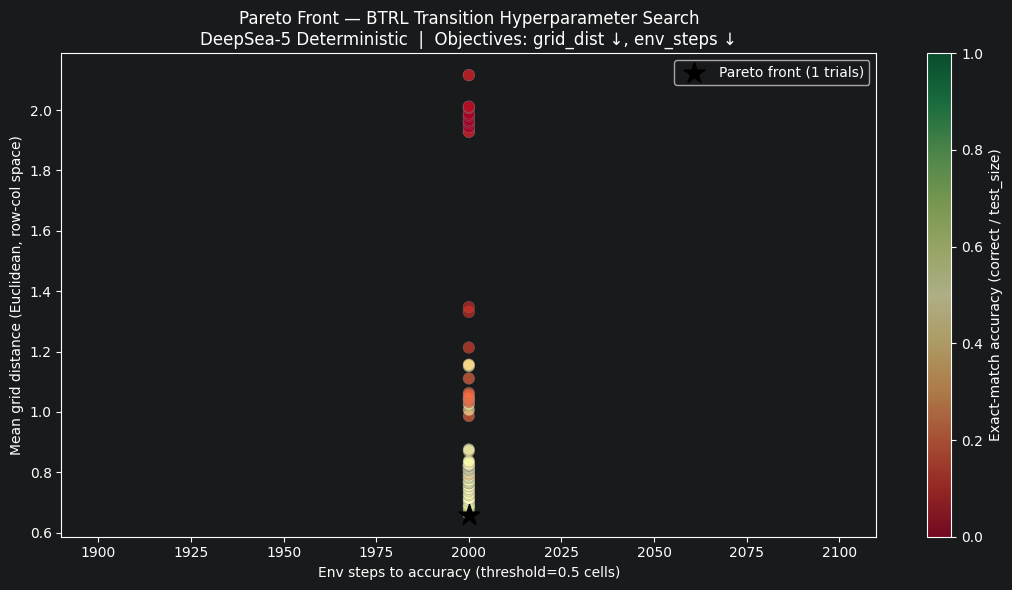


Pareto-front configs:
 mean_grid_dist  env_steps_to_accuracy  hidden_dim   p_seq  p_attn  accuracy
        0.65956             2000.00000          64 0.30000 0.15000   0.50000


In [14]:
pareto_df = pd.DataFrame([{
    'mean_grid_dist':       t.values[0],
    'env_steps_to_accuracy': t.values[1],
    'hidden_dim':           t.user_attrs.get('hidden_dim'),
    'p_seq':                t.user_attrs.get('p_seq'),
    'p_attn':               t.user_attrs.get('p_attn'),
    'accuracy':             t.user_attrs.get('correct_preds', 0) /
                            max(t.user_attrs.get('test_size', 1), 1),
} for t in study.best_trials])

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    results_df['env_steps_to_accuracy'], results_df['mean_grid_dist'],
    c=results_df['accuracy'], cmap='RdYlGn', alpha=0.65, s=70,
    vmin=0, vmax=1, edgecolors='grey', linewidths=0.3,
)
ax.scatter(
    pareto_df['env_steps_to_accuracy'], pareto_df['mean_grid_dist'],
    color='black', marker='*', s=250,
    label=f'Pareto front ({len(pareto_df)} trials)', zorder=5,
)
plt.colorbar(sc, ax=ax, label='Exact-match accuracy (correct / test_size)')
ax.set_xlabel(f'Env steps to accuracy (threshold={TARGET_GRID_DIST} cells)')
ax.set_ylabel('Mean grid distance (Euclidean, row-col space)')
ax.set_title(
    'Pareto Front — BTRL Transition Hyperparameter Search\n'
    'DeepSea-5 Deterministic  |  Objectives: grid_dist ↓, env_steps ↓'
)
ax.legend()
plt.tight_layout()
plt.show()

print('\nPareto-front configs:')
print(pareto_df.sort_values('mean_grid_dist').to_string(index=False))

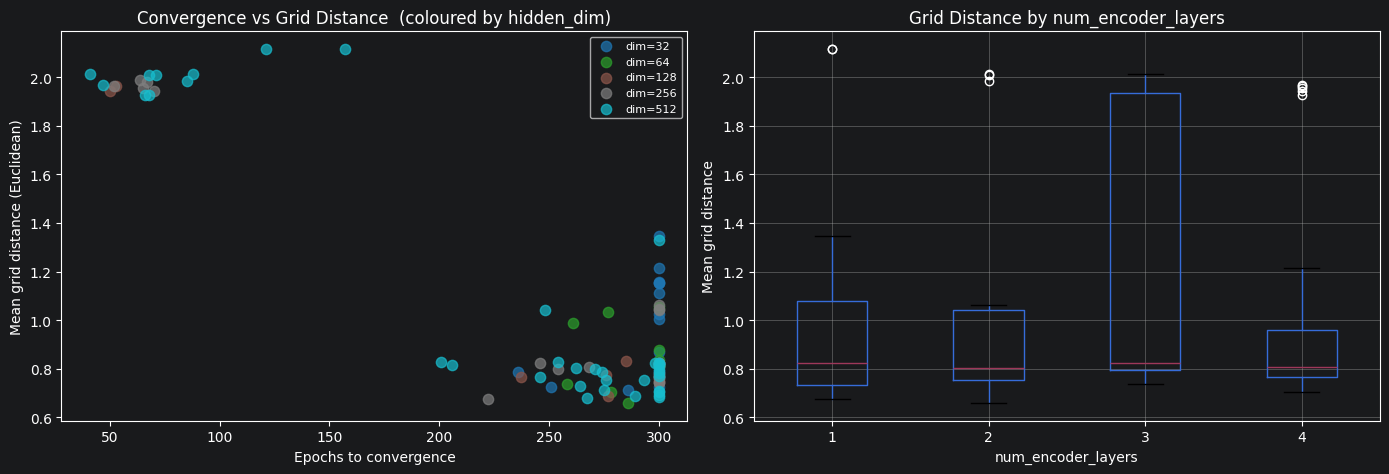

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: epochs vs grid distance, coloured by hidden_dim
dims   = sorted(results_df['hidden_dim'].dropna().unique())
cmap_d = plt.cm.get_cmap('tab10', len(dims))
for i, d in enumerate(dims):
    sub = results_df[results_df['hidden_dim'] == d]
    axes[0].scatter(
        sub['epochs_to_converge'], sub['mean_grid_dist'],
        label=f'dim={int(d)}', color=cmap_d(i), alpha=0.7, s=55,
    )
axes[0].set_xlabel('Epochs to convergence')
axes[0].set_ylabel('Mean grid distance (Euclidean)')
axes[0].set_title('Convergence vs Grid Distance  (coloured by hidden_dim)')
axes[0].legend(fontsize=8)

# Right: grid distance distribution by num_encoder_layers
results_df.boxplot(column='mean_grid_dist', by='num_encoder_layers', ax=axes[1])
axes[1].set_title('Grid Distance by num_encoder_layers')
axes[1].set_xlabel('num_encoder_layers')
axes[1].set_ylabel('Mean grid distance')
plt.suptitle('')

plt.tight_layout()
plt.show()


In [16]:
cols = ['trial', 'hidden_dim', 'heads', 'learning_rate', 'num_encoder_layers',
        'forward_expansion', 'p_seq', 'p_attn', 'mean_grid_dist', 'mean_grid_variance',
        'env_steps_to_accuracy', 'epochs_to_converge', 'accuracy', 'best_loss']

print('Top 5 — lowest mean grid distance (most spatially accurate posterior):')
display(results_df.nsmallest(5, 'mean_grid_dist')[cols])

print('\nTop 5 — fewest env steps to accuracy:')
display(results_df.nsmallest(5, 'env_steps_to_accuracy')[cols])

print('\nTop 5 — highest exact-match accuracy:')
display(results_df.nlargest(5, 'accuracy')[cols])

# Best balanced: minimise normalised grid_dist + env_steps + (1 - accuracy)
r = results_df.copy()
def norm(col): return (col - col.min()) / (col.max() - col.min() + 1e-9)
r['score'] = norm(r['mean_grid_dist']) + norm(r['env_steps_to_accuracy']) + (1 - r['accuracy'])
best_idx   = r['score'].idxmin()

print('\nBest balanced trial (min normalised grid_dist + env_steps + accuracy_loss):')
display(r.loc[[best_idx], cols + ['score']])

Top 5 — lowest mean grid distance (most spatially accurate posterior):


,trial,hidden_dim,heads,learning_rate,num_encoder_layers,forward_expansion,p_seq,p_attn,mean_grid_dist,mean_grid_variance,env_steps_to_accuracy,epochs_to_converge,accuracy,best_loss
0,28,64,8,0.00357,2,2,0.30000,0.15000,0.65956,0.10274,2000,286,0.50000,0.59183
1,70,256,1,0.00112,1,2,0.10000,0.15000,0.67456,0.49939,2000,222,0.60000,0.57347
2,87,512,4,0.00080,1,2,0.05000,0.02000,0.68155,0.14480,2000,267,0.60000,0.56796
3,27,512,1,0.00037,1,8,0.10000,0.10000,0.68522,0.13988,2000,300,0.56667,0.57123
4,18,512,2,0.00043,1,4,0.30000,0.10000,0.68849,0.15253,2000,289,0.56667,0.57281



Top 5 — fewest env steps to accuracy:


,trial,hidden_dim,heads,learning_rate,num_encoder_layers,forward_expansion,p_seq,p_attn,mean_grid_dist,mean_grid_variance,env_steps_to_accuracy,epochs_to_converge,accuracy,best_loss
0,28,64,8,0.00357,2,2,0.30000,0.15000,0.65956,0.10274,2000,286,0.50000,0.59183
1,70,256,1,0.00112,1,2,0.10000,0.15000,0.67456,0.49939,2000,222,0.60000,0.57347
2,87,512,4,0.00080,1,2,0.05000,0.02000,0.68155,0.14480,2000,267,0.60000,0.56796
3,27,512,1,0.00037,1,8,0.10000,0.10000,0.68522,0.13988,2000,300,0.56667,0.57123
4,18,512,2,0.00043,1,4,0.30000,0.10000,0.68849,0.15253,2000,289,0.56667,0.57281



Top 5 — highest exact-match accuracy:


,trial,hidden_dim,heads,learning_rate,num_encoder_layers,forward_expansion,p_seq,p_attn,mean_grid_dist,mean_grid_variance,env_steps_to_accuracy,epochs_to_converge,accuracy,best_loss
1,70,256,1,0.00112,1,2,0.10000,0.15000,0.67456,0.49939,2000,222,0.60000,0.57347
2,87,512,4,0.00080,1,2,0.05000,0.02000,0.68155,0.14480,2000,267,0.60000,0.56796
6,85,512,1,0.00037,1,2,0.10000,0.15000,0.69149,0.22326,2000,300,0.60000,0.57386
3,27,512,1,0.00037,1,8,0.10000,0.10000,0.68522,0.13988,2000,300,0.56667,0.57123
4,18,512,2,0.00043,1,4,0.30000,0.10000,0.68849,0.15253,2000,289,0.56667,0.57281



Best balanced trial (min normalised grid_dist + env_steps + accuracy_loss):


,trial,hidden_dim,heads,learning_rate,num_encoder_layers,forward_expansion,p_seq,p_attn,mean_grid_dist,mean_grid_variance,env_steps_to_accuracy,epochs_to_converge,accuracy,best_loss,score
1,70,256,1,0.00112,1,2,0.10000,0.15000,0.67456,0.49939,2000,222,0.60000,0.57347,0.41030


Retraining best balanced model:
  hidden_dim            : 256.0
  heads                 : 1.0
  learning_rate         : 0.0011194966005419896
  num_encoder_layers    : 1.0
  forward_expansion     : 2.0
  p_seq                 : 0.1
  p_attn                : 0.15
  mean_grid_dist        : 0.6745566666666666
  env_steps_to_accuracy : 2000.0
  epochs_to_converge    : 222.0
  accuracy              : 0.6


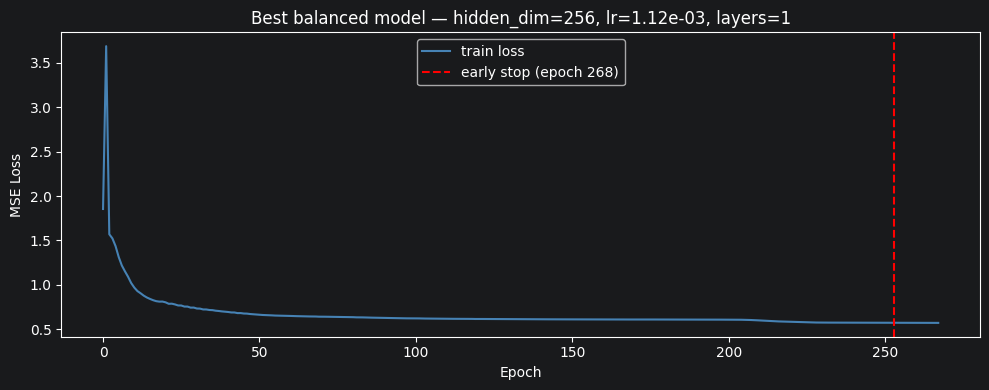

Converged at epoch : 268  |  Best loss : 0.571075
Saved optimal parameters → configs/optimal_transition_params.json
{
  "hidden_dim": 256,
  "heads": 1,
  "learning_rate": 0.0011194966005419896,
  "num_encoder_layers": 1,
  "forward_expansion": 2,
  "p_seq": 0.1,
  "p_attn": 0.15,
  "context_length": 2,
  "mean_grid_dist": 0.6745566666666666,
  "env_steps_to_accuracy": 2000,
  "accuracy": 0.6,
  "epochs_to_converge": 222,
  "final_loss": 0.5710746645927429,
  "env": "5",
  "deterministic": true,
  "n_trials": 100,
  "data_samples": 2000
}


In [17]:
# Re-identify best balanced row (recompute in case cell is re-run independently)
r2 = results_df.copy()
def norm2(col): return (col - col.min()) / (col.max() - col.min() + 1e-9)
r2['score'] = norm2(r2['mean_grid_dist']) + norm2(r2['env_steps_to_accuracy']) + (1 - r2['accuracy'])
best_row = r2.loc[r2['score'].idxmin()]

print('Retraining best balanced model:')
for k in ['hidden_dim', 'heads', 'learning_rate', 'num_encoder_layers',
          'forward_expansion', 'p_seq', 'p_attn', 'mean_grid_dist',
          'env_steps_to_accuracy', 'epochs_to_converge', 'accuracy']:
    print(f'  {k:22s}: {best_row[k]}')

best_cfg = dict(config['transition'])
best_cfg['hidden_dim']         = int(best_row['hidden_dim'])
best_cfg['heads']              = int(best_row['heads'])
best_cfg['learning_rate']      = float(best_row['learning_rate'])
best_cfg['num_encoder_layers'] = int(best_row['num_encoder_layers'])
best_cfg['forward_expansion']  = int(best_row['forward_expansion'])

best_model = TransitionNetwork(
    best_cfg, obs_space, possible_actions,
    p_seq=float(best_row.get('p_seq', 0.2)),
    p_attn=float(best_row.get('p_attn', 0.05)),
    max_steps=int(torch.max(timesteps).item()) + 1,
    device=torch.device('cpu'),
)
best_opt = torch.optim.Adam(best_model.parameters(), lr=best_cfg['learning_rate'])

loss_hist, conv_ep, final_loss = early_stopping_train(
    best_model, states, next_states, timesteps, actions, rewards, best_opt,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, min_delta=MIN_DELTA,
)

plt.figure(figsize=(10, 4))
plt.plot(loss_hist, label='train loss', color='steelblue')
if conv_ep < MAX_EPOCHS:
    plt.axvline(conv_ep - PATIENCE, color='red', linestyle='--',
                label=f'early stop (epoch {conv_ep})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
dim_h = int(best_row['hidden_dim'])
lr_v  = best_row['learning_rate']
plt.title(f'Best balanced model — hidden_dim={dim_h}, lr={lr_v:.2e}, '
          f'layers={int(best_row["num_encoder_layers"])}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Converged at epoch : {conv_ep}  |  Best loss : {final_loss:.6f}')

# ── Save optimal parameters to JSON ─────────────────────────────────────────
optimal_params = {
    'hidden_dim':         int(best_row['hidden_dim']),
    'heads':              int(best_row['heads']),
    'learning_rate':      float(best_row['learning_rate']),
    'num_encoder_layers': int(best_row['num_encoder_layers']),
    'forward_expansion':  int(best_row['forward_expansion']),
    'p_seq':              float(best_row.get('p_seq', 0.2)),
    'p_attn':             float(best_row.get('p_attn', 0.05)),
    'context_length':     int(config['transition']['context_length']),
    'mean_grid_dist':     float(best_row['mean_grid_dist']),
    'env_steps_to_accuracy': int(best_row['env_steps_to_accuracy']),
    'accuracy':           float(best_row['accuracy']),
    'epochs_to_converge': int(best_row['epochs_to_converge']),
    'final_loss':         float(final_loss),
    'env':                config['experiment']['env'],
    'deterministic':      config['experiment']['deterministic'],
    'n_trials':           N_TRIALS,
    'data_samples':       TIME_LIMIT,
}

out_path = Path('configs/optimal_transition_params.json')
with open(out_path, 'w') as f:
    json.dump(optimal_params, f, indent=2)

print(f'Saved optimal parameters → {out_path}')
print(json.dumps(optimal_params, indent=2))

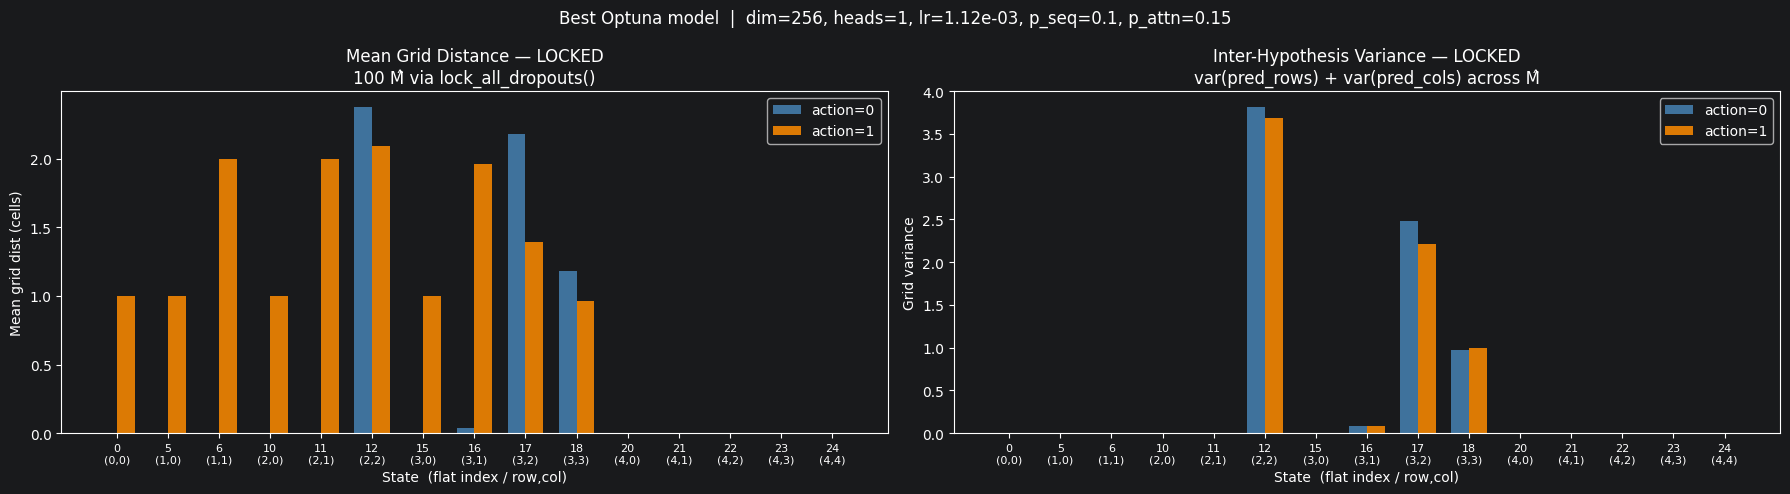

Correct: 18/30  | mean_grid_dist=0.6727  | grid_var=0.4772

Per-state prediction summary:


,current_state,action,true next_state,true_row,true_col,pred next_state,pred_row,pred_col,mean_grid_dist,grid_variance,exact_match
0,0,0,5,1,0,5,1,0,0.00000,0.00000,1
1,0,1,6,1,1,5,1,0,1.00000,0.00000,0
2,5,0,10,2,0,10,2,0,0.00000,0.00000,1
3,5,1,11,2,1,10,2,0,1.00000,0.00000,0
4,6,0,10,2,0,10,2,0,0.00000,0.00000,1
5,6,1,12,2,2,10,2,0,2.00000,0.00000,0
6,10,0,15,3,0,15,3,0,0.00000,0.00000,1
7,10,1,16,3,1,15,3,0,1.00000,0.00000,0
8,11,0,15,3,0,15,3,0,0.00000,0.00000,1
9,11,1,17,3,2,15,3,0,2.00000,0.00000,0


In [18]:
# ── Locked evaluation: per-state grid distance and inter-hypothesis variance ──
# N_HYPOTHESES different M̂ are sampled (lock → predict all test cases → unlock).
# X-axis: actual state flat indices (whole numbers) so position is meaningful.
# Only reachable states appear (impossible states are never visited by the env).

res = test_model_locked(best_model, test_transitions, possible_actions,
                        n_hypotheses=N_HYPOTHESES)

N_grid        = int(round(obs_space ** 0.5))
states_sorted = sorted(res['current_state'].unique())
action_vals   = sorted(res['action'].unique())
n_states      = len(states_sorted)
x             = np.arange(n_states)
bar_w         = 0.35

# Label each tick as "flat_idx\n(row,col)"
xtick_labels = [f'{s}\n({s//N_grid},{s%N_grid})' for s in states_sorted]

fig, axes = plt.subplots(1, 2, figsize=(max(14, n_states * 1.2), 5))

colors = ['steelblue', 'darkorange']
for i, a in enumerate(action_vals):
    sub    = res[res['action'] == a].set_index('current_state').reindex(states_sorted)
    offset = (i - (len(action_vals) - 1) / 2) * bar_w
    axes[0].bar(x + offset, sub['mean_grid_dist'].fillna(0).values, bar_w,
                label=f'action={int(a)}', color=colors[i], alpha=0.85)
    axes[1].bar(x + offset, sub['grid_variance'].fillna(0).values, bar_w,
                label=f'action={int(a)}', color=colors[i], alpha=0.85)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.legend()
    ax.set_xlabel('State  (flat index / row,col)')

axes[0].set_ylabel('Mean grid dist (cells)')
axes[0].set_title(f'Mean Grid Distance — LOCKED\n{N_HYPOTHESES} M̂ via lock_all_dropouts()')

axes[1].set_ylabel('Grid variance')
axes[1].set_title('Inter-Hypothesis Variance — LOCKED\nvar(pred_rows) + var(pred_cols) across M̂')

dim_h  = int(best_row['hidden_dim'])
lr_v   = best_row['learning_rate']
p_seq  = best_row.get('p_seq', 0.2)
p_attn = best_row.get('p_attn', 0.05)
plt.suptitle(
    f'Best Optuna model  |  dim={dim_h}, heads={int(best_row["heads"])}, '
    f'lr={lr_v:.2e}, p_seq={p_seq}, p_attn={p_attn}',
    fontsize=12,
)
plt.tight_layout()
plt.show()

n_correct = int(res['exact_match'].sum())
print(f'Correct: {n_correct}/{len(res)}  '
      f'| mean_grid_dist={res["mean_grid_dist"].mean():.4f}  '
      f'| grid_var={res["grid_variance"].mean():.4f}')
print()
print('Per-state prediction summary:')
display(res[['current_state', 'action', 'true next_state', 'true_row', 'true_col',
             'pred next_state', 'pred_row', 'pred_col',
             'mean_grid_dist', 'grid_variance', 'exact_match']]
        .sort_values(['current_state', 'action'])
        .reset_index(drop=True))